In [14]:
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW3')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('Hitters_train.csv')
test_df = pd.read_csv('Hitters_test.csv')

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print(train_df.columns.tolist())

feature_cols = ['Years', 'Hits', 'RBI', 'Walks', 'Runs']
X_train = train_df[feature_cols].values
y_train = train_df['Salary'].values

X_test = test_df[feature_cols].values
y_test = test_df['Salary'].values

# deal with missing values
X_train = np.nan_to_num(X_train, nan=0)  # feature missing values filled with 0
X_test = np.nan_to_num(X_test, nan=0)
y_train = np.nan_to_num(y_train, nan=np.nanmedian(y_train))  # use median to fill missing Salary
y_test = np.nan_to_num(y_test, nan=np.nanmedian(y_test))

print(f"Features: {feature_cols}")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
global_median = np.median(y_train)
total_abs_loss = np.sum(np.abs(y_train - global_median))
print(f"Total absolute loss (for min_gain reference): {total_abs_loss:.3f}")

Training set shape: (222, 20)
Test set shape: (100, 20)
['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague']
Features: ['Years', 'Hits', 'RBI', 'Walks', 'Runs']
Training set: (222, 5), Test set: (100, 5)
Total absolute loss (for min_gain reference): 136.862


In [15]:
class RegressionTree:
    def __init__(self, max_leaf_nodes=None, min_gain=0.0):
        self.max_leaf_nodes = max_leaf_nodes
        self.min_gain = min_gain
        self.tree = None

    def _absolute_loss(self, y):
        if len(y) == 0:
            return 0
        median = np.median(y)
        return np.sum(np.abs(y - median))

    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        if n_samples <= 1:
            return None, None, None

        best_gain = 0
        best_feature = None
        best_threshold = None

        for feature_idx in range(n_features):
            unique_vals = np.unique(X[:, feature_idx])
            for i in range(len(unique_vals) - 1):
                threshold = (unique_vals[i] + unique_vals[i+1]) / 2.0
                
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_y = y[left_mask]
                right_y = y[right_mask]

                loss_before = self._absolute_loss(y)
                loss_after = self._absolute_loss(left_y) + self._absolute_loss(right_y)
                gain = loss_before - loss_after

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        # if the best gain is less than min_gain, do not split
        if best_gain < self.min_gain:
            return None, None, None

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, leaf_count=[1]):
        # 检查是否达到最大叶子数
        if self.max_leaf_nodes is not None and leaf_count[0] >= self.max_leaf_nodes:
            return {'leaf': True, 'value': np.median(y)}
        
        if len(y) <= 1:
            return {'leaf': True, 'value': np.median(y)}

        best_feature, best_threshold, best_gain = self._find_best_split(X, y)

        if best_feature is None:
            return {'leaf': True, 'value': np.median(y)}

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        # 关键：检查分裂后是否会超限
        if self.max_leaf_nodes is not None and leaf_count[0] + 1 > self.max_leaf_nodes:
            return {'leaf': True, 'value': np.median(y)}

        # 执行分裂
        leaf_count[0] += 1

        left_tree = self._build_tree(X[left_mask], y[left_mask], leaf_count)
        right_tree = self._build_tree(X[right_mask], y[right_mask], leaf_count)

        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_tree,
            'right': right_tree
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, [1])  # 初始叶子数=1

    def _predict_one(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    def get_leaf_count(self):
        def count_leaves(node):
            if node['leaf']:
                return 1
            return count_leaves(node['left']) + count_leaves(node['right'])
        return count_leaves(self.tree)

In [17]:
# Train and evaluate the regression tree with hyperparameter tuning

min_gain_list = [0.0, total_abs_loss * 0.001, total_abs_loss * 0.005, total_abs_loss * 0.01]
min_gain_list = [float(x) for x in min_gain_list]

max_leaf_list = [5, 10, 15, 20]

best_test_error = float('inf')
best_params = {}
best_tree = None

for max_leaf in max_leaf_list:
    for min_gain in min_gain_list:
        print(f"\nTrying max_leaf={max_leaf}, min_gain={min_gain:.3f}")
        
        reg_tree = RegressionTree(max_leaf_nodes=max_leaf, min_gain=min_gain)
        reg_tree.fit(X_train, y_train)  # ✅ 修正：用 X_train, y_train
        
        y_train_pred = reg_tree.predict(X_train)
        train_mae = np.mean(np.abs(y_train - y_train_pred))
        
        y_test_pred = reg_tree.predict(X_test)
        test_mae = np.mean(np.abs(y_test - y_test_pred))
        
        print(f"Train MAE: {train_mae:.3f}, Test MAE: {test_mae:.3f}")
        print(f"Number of leaves: {reg_tree.get_leaf_count()}")
        
        if test_mae < best_test_error:
            best_test_error = test_mae
            best_params = {'max_leaf': max_leaf, 'min_gain': min_gain}
            best_tree = reg_tree

print("Final Best Model:")
print(f"Best Parameters: {best_params}")
print(f"Best Test MAE: {best_test_error:.3f}")
print(f"Final number of leaves: {best_tree.get_leaf_count()}")




Trying max_leaf=5, min_gain=0.000
Train MAE: 0.468, Test MAE: 0.557
Number of leaves: 5

Trying max_leaf=5, min_gain=0.137
Train MAE: 0.468, Test MAE: 0.557
Number of leaves: 5

Trying max_leaf=5, min_gain=0.684
Train MAE: 0.468, Test MAE: 0.557
Number of leaves: 5

Trying max_leaf=5, min_gain=1.369
Train MAE: 0.392, Test MAE: 0.438
Number of leaves: 5

Trying max_leaf=10, min_gain=0.000
Train MAE: 0.451, Test MAE: 0.563
Number of leaves: 10

Trying max_leaf=10, min_gain=0.137
Train MAE: 0.449, Test MAE: 0.563
Number of leaves: 10

Trying max_leaf=10, min_gain=0.684
Train MAE: 0.363, Test MAE: 0.453
Number of leaves: 10

Trying max_leaf=10, min_gain=1.369
Train MAE: 0.349, Test MAE: 0.482
Number of leaves: 10

Trying max_leaf=15, min_gain=0.000
Train MAE: 0.448, Test MAE: 0.563
Number of leaves: 15

Trying max_leaf=15, min_gain=0.137
Train MAE: 0.439, Test MAE: 0.587
Number of leaves: 15

Trying max_leaf=15, min_gain=0.684
Train MAE: 0.336, Test MAE: 0.467
Number of leaves: 15

Trying

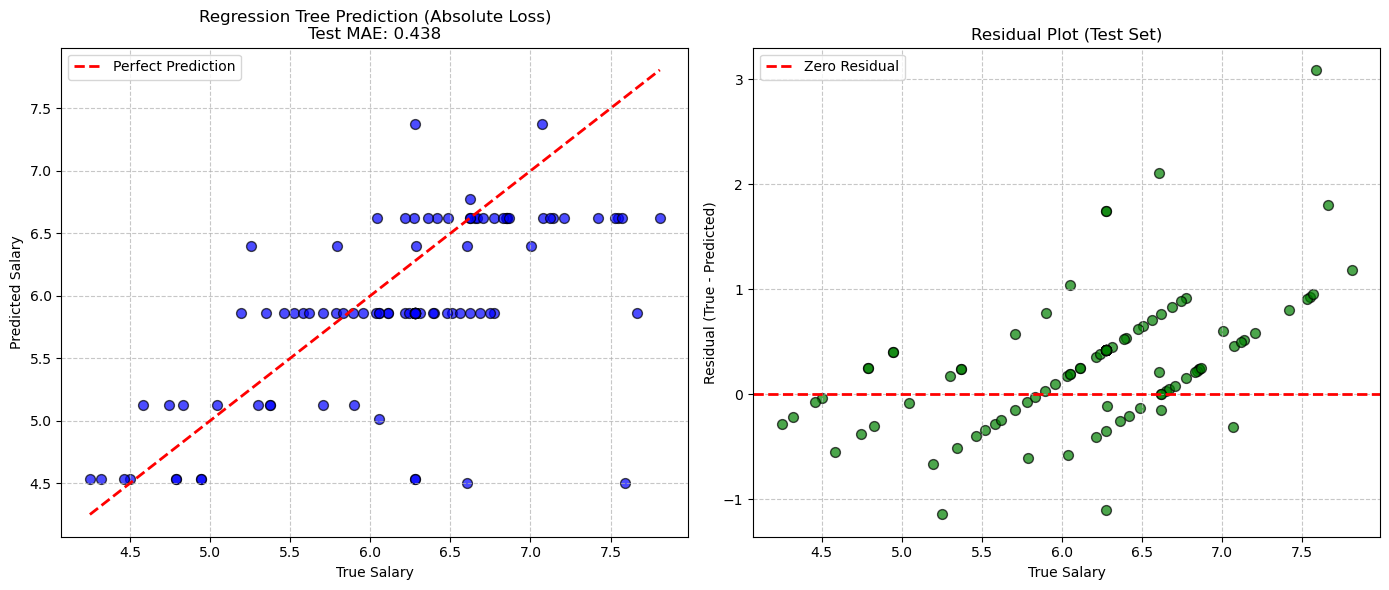

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图1：Predicted vs True
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.7, color='blue', edgecolors='k', s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('True Salary')
ax1.set_ylabel('Predicted Salary')
ax1.set_title(f'Regression Tree Prediction (Absolute Loss)\nTest MAE: {best_test_error:.3f}')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 图2：Residual Plot
ax2 = axes[1]
residuals = y_test - y_test_pred
ax2.scatter(y_test, residuals, alpha=0.7, color='green', edgecolors='k', s=50)
ax2.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')
ax2.set_xlabel('True Salary')
ax2.set_ylabel('Residual (True - Predicted)')
ax2.set_title('Residual Plot (Test Set)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()